In [ ]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor


# 학습 모델 저장을 위한 라이브러리
import pickle

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,123 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126281 files and dire

In [ ]:
# 폰트 설정
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

### 프로젝트 셋팅

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = '/content/drive/MyDrive/은서님 파일/best_model_cd_8.dat'
# 교차검증 횟수
cv_count = 10
# 교차 검증
kfold = KFold(n_splits=cv_count, shuffle=True, random_state=1)
# 평가 결과를 담을 리스트
# 필요하다면 다른 것도 만들어주세요
f1_score_list = []
# 학습 모델 이름
model_name_list = []

### 데이터 준비
- 데이터를 읽어오고 필요한 전처리까지 다 한다음 입력데이터는 train_X, 결과데이터는 train_y라는 변수에 담아서 준비해주세요

In [ ]:
plus_df = pd.read_parquet('/content/drive/MyDrive/abcde/cd추가컬럼_df.parquet')

In [ ]:
plus_df.columns

Index(['ID', '기준년월', 'Segment', '연체입금원금_B5M', '연체입금원금_B2M', '이용건수_오프라인_R3M',
       '이용개월수_신용_R3M', '이용카드수_신용', '_1순위카드이용건수', '이용건수_오프라인_R6M',
       ...
       '할부금액_무이자_6M_R12M', '잔액_신판평균한도소진율_r3m', '교통_택시이용금액', '이용개월수_할부_무이자_R6M',
       'RP건수_B0M', '이용금액_할부_R6M', '입회일자_신용', '입회경과개월수_신용', '잔액_신판평균한도소진율_r6m',
       '이용개월수_할부_R3M'],
      dtype='object', length=115)

In [ ]:
# 데이터를 읽어온다.
train_df = pd.read_parquet('/content/drive/MyDrive/은서님 파일/Seleted(C_D)_delecteABE_all_train.parquet')
test_df = pd.read_parquet('/content/drive/MyDrive/abcde/ab_cde_test.parquet')

display(train_df)
display(test_df)

,기준년월,ID,Segment,이용금액_R3M_신용체크,_1순위카드이용금액,이용금액_R3M_신용,이용카드수_신용체크,Life_Stage,이용개월수_신용_R12M,이용개월수_신판_R12M,...,청구금액_R3M,청구금액_B0,청구서발송여부_B0,할인건수_R3M,할인건수_B0M,방문횟수_앱_R6M,방문횟수_PC_R6M,방문일수_PC_R6M,인입횟수_ARS_R6M,이용메뉴건수_ARS_R6M
0,201807,TRAIN_000000,D,196,3681,196,1,자녀성장(2),12,12,...,46588,12226,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상,10회 이상
1,201807,TRAIN_000002,C,23988,24493,23988,1,자녀출산기,9,9,...,85931,21866,1,1회 이상,1회 이상,30회 이상,10회 이상,10회 이상,1회 이상,1회 이상
2,201807,TRAIN_000003,D,3904,5933,3904,1,자녀성장(2),12,12,...,61518,16356,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상,10회 이상
3,201807,TRAIN_000008,C,124967,68078,121279,5,자녀출산기,12,12,...,62715,20512,1,10회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
4,201807,TRAIN_000010,D,21001,18796,21001,1,자녀성장(1),12,12,...,30449,22512,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476827,201812,TRAIN_399979,D,31187,27337,31187,2,자녀성장(2),12,12,...,41812,11817,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
476828,201812,TRAIN_399987,C,42492,35751,42492,1,자녀성장(2),12,12,...,68356,17859,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상,30회 이상
476829,201812,TRAIN_399993,C,72348,27792,72348,4,자녀성장(1),12,12,...,34890,10810,1,20회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상
476830,201812,TRAIN_399996,D,27636,26357,27636,1,자녀성장(2),12,12,...,37515,14402,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상


,기준년월,ID,남녀구분코드,연령,회원여부_이용가능,회원여부_이용가능_CA,회원여부_이용가능_카드론,소지여부_신용,소지카드수_유효_신용,소지카드수_이용가능_신용,...,잔액_신판ca최대한도소진율_r3m,변동률_일시불평잔,변동률_RV일시불평잔,변동률_할부평잔,변동률_CA평잔,변동률_RVCA평잔,변동률_카드론평잔,변동률_잔액_B1M,변동률_잔액_일시불_B1M,변동률_잔액_CA_B1M
0,201807,TEST_00000,1,40대,1,1,0,1,2,2,...,0.145300,1.463214,0.999998,0.999998,0.999998,0.999998,0.999998,0.209395,0.231043,0.0
1,201807,TEST_00001,1,60대,1,1,0,1,1,1,...,0.324844,1.315412,0.999998,1.044473,1.991974,0.999998,0.926569,-0.269161,-0.247241,0.0
2,201807,TEST_00002,1,40대,1,1,1,1,2,2,...,0.221608,1.055927,0.999998,1.053083,0.999998,0.999998,0.999998,-0.120290,0.029270,0.0
3,201807,TEST_00003,2,40대,1,1,1,1,1,1,...,0.128337,1.488069,0.999998,1.991630,0.999998,0.999998,0.999998,0.035807,-0.013359,0.0
4,201807,TEST_00004,2,40대,1,0,1,1,1,1,...,0.737263,1.208739,0.999998,1.053743,0.999998,0.999998,0.999998,-0.538740,-0.449378,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,201812,TEST_99995,2,60대,0,0,0,0,0,0,...,0.000000,0.999998,0.999998,0.999998,0.999998,0.999998,0.999998,0.000000,0.000000,0.0
599996,201812,TEST_99996,1,30대,1,1,1,1,1,1,...,0.000000,0.894539,0.999998,0.999998,0.999998,0.999998,0.999998,0.143554,0.233616,0.0
599997,201812,TEST_99997,2,30대,1,1,1,1,1,1,...,0.013292,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
599998,201812,TEST_99998,1,30대,1,1,1,1,3,3,...,0.379777,0.809328,0.999998,0.333183,0.999998,0.999998,0.999998,-0.038153,-0.106142,0.0


In [ ]:
train_df = train_df.merge(plus_df, on=['ID','기준년월','Segment'], how='inner')

In [ ]:
train_df.columns

Index(['기준년월', 'ID', 'Segment', '이용금액_R3M_신용체크', '_1순위카드이용금액', '이용금액_R3M_신용',
       '이용카드수_신용체크', 'Life_Stage', '이용개월수_신용_R12M', '이용개월수_신판_R12M',
       ...
       '할부금액_무이자_6M_R12M', '잔액_신판평균한도소진율_r3m', '교통_택시이용금액', '이용개월수_할부_무이자_R6M',
       'RP건수_B0M', '이용금액_할부_R6M', '입회일자_신용', '입회경과개월수_신용', '잔액_신판평균한도소진율_r6m',
       '이용개월수_할부_R3M'],
      dtype='object', length=174)

In [ ]:
train_df['이용건수_오프라인_R3M']

,이용건수_오프라인_R3M
0,17
1,33
2,19
3,262
4,6
...,...
476827,73
476828,58
476829,164
476830,24


In [ ]:

# 이용건수_오프라인_R3M
# 이용개월수_신용_R3M
# 이용카드수_신용
# _1순위카드이용건수
# 이용건수_오프라인_R6M
# 청구서발송여부_R3M
# 최대이용금액_일시불_R12M
# 이용개월수_신판_R3M


In [ ]:

# 이용개월수_일시불_R3M
# 쇼핑_도소매_이용금액
# _1순위교통업종_이용금액
# 최종이용일자_할부
# 이용후경과월_일시불
# 연속무실적개월수_기본_24M_카드
# 이용개월수_온라인_R6M
# 이용가능카드수_신용체크
# 쇼핑_슈퍼마켓_이용금액
# _1순위업종_이용금액
# 이용개월수_간편결제_R6M
# 이용개월수_페이_온라인_R6M
# 유효카드수_신용체크
# 평잔_일시불_6M
# 이용여부_3M_해외겸용_본인
# 쇼핑_마트_이용금액
# 이용가능카드수_신용
# 교통_주유이용금액
# 이용건수_간편결제_R3M
# 이용건수_간편결제_B0M
# 이용건수_간편결제_R6M
# 평잔_일시불_3M
# 월중평잔_일시불
# 월중평잔_일시불_B0M
# _2순위카드이용건수


In [ ]:
# ['청구서발송여부_R6M',
# '이용후경과월_할부',
# '_2순위교통업종_이용금액',
# '이용건수_페이_온라인_R6M',
# '이용후경과월_할부_무이자',
# '유효카드수_신용',
# '이용건수_온라인_B0M',
# '_2순위카드이용금액',
# '이용건수_온라인_R3M',
# '이용개월수_할부_R12M',
# '잔액_일시불_B0M',
# '이용건수_페이_온라인_R3M',
# '이용건수_온라인_R6M',
# '최대이용금액_할부_R12M',
# '이용금액_페이_온라인_B0M',
# '소지카드수_이용가능_신용',
# '이용개월수_할부_무이자_R12M',
# '이용건수_페이_온라인_B0M',
# '이용여부_3M_해외겸용_신용_본인',
# '변동률_RVCA평잔',
# '이용금액_온라인_B0M',
# '이용개월수_결제일_R6M',
# '잔액_신판ca최대한도소진율_r6m',
# '최종이용일자_일시불',


['최대이용금액_할부_무이자_R12M',
'소지카드수_유효_신용',
'변동률_RV일시불평잔',
'혜택수혜금액',
'이용금액_할부_R12M',
'최종이용일자_신판',
'쇼핑_기타_이용금액',
'최종이용일자_기본',
'혜택수혜금액_R3M',
'이용금액_간편결제_B0M',
'이용금액_페이_온라인_R3M',
'잔액_신판ca최대한도소진율_r3m',
'쇼핑_편의점_이용금액',
'잔액_일시불_B2M',
'잔액_일시불_B1M',
'_1순위쇼핑업종_이용금액',
'이용개월수_결제일_R3M',
'잔액_신판ca평균한도소진율_r3m',
'이용금액_페이_온라인_R6M',
'잔액_신판ca평균한도소진율_r6m',
'컨택건수_이용유도_TM_R6M',
'CA한도금액',
'연체입금원금_B0M',
'할부금액_6M_R12M',
'이용금액_온라인_R6M',
'카드이용한도금액',
'잔액_신판최대한도소진율_r6m',
'이용금액_간편결제_R3M',
'이용금액_할부_무이자_R12M',
'_3순위교통업종_이용금액',
'카드이용한도금액_B1M',
'카드이용한도금액_B2M',
'이용건수_할부_R12M',
'할부금액_3M_R12M',
'이용개월수_할부_R6M',
'_1순위납부업종_이용금액',
'최종이용일자_CA',
'잔액_신판최대한도소진율_r3m',
'이용가능여부_해외겸용_본인',
'이용금액_간편결제_R6M',
'할부건수_3M_R12M',
'상환개월수_결제일_R6M',
'이용건수_할부_무이자_R12M',
'할부금액_무이자_6M_R12M',
'잔액_신판평균한도소진율_r3m',
'교통_택시이용금액',
'이용개월수_할부_무이자_R6M',
'RP건수_B0M',
'이용금액_할부_R6M',
'입회일자_신용',
'입회경과개월수_신용',
'잔액_신판평균한도소진율_r6m',
'이용개월수_할부_R3M'
]


['최대이용금액_할부_무이자_R12M',
 '소지카드수_유효_신용',
 '변동률_RV일시불평잔',
 '혜택수혜금액',
 '이용금액_할부_R12M',
 '최종이용일자_신판',
 '쇼핑_기타_이용금액',
 '최종이용일자_기본',
 '혜택수혜금액_R3M',
 '이용금액_간편결제_B0M',
 '이용금액_페이_온라인_R3M',
 '잔액_신판ca최대한도소진율_r3m',
 '쇼핑_편의점_이용금액',
 '잔액_일시불_B2M',
 '잔액_일시불_B1M',
 '_1순위쇼핑업종_이용금액',
 '이용개월수_결제일_R3M',
 '잔액_신판ca평균한도소진율_r3m',
 '이용금액_페이_온라인_R6M',
 '잔액_신판ca평균한도소진율_r6m',
 '컨택건수_이용유도_TM_R6M',
 'CA한도금액',
 '연체입금원금_B0M',
 '할부금액_6M_R12M',
 '이용금액_온라인_R6M',
 '카드이용한도금액',
 '잔액_신판최대한도소진율_r6m',
 '이용금액_간편결제_R3M',
 '이용금액_할부_무이자_R12M',
 '_3순위교통업종_이용금액',
 '카드이용한도금액_B1M',
 '카드이용한도금액_B2M',
 '이용건수_할부_R12M',
 '할부금액_3M_R12M',
 '이용개월수_할부_R6M',
 '_1순위납부업종_이용금액',
 '최종이용일자_CA',
 '잔액_신판최대한도소진율_r3m',
 '이용가능여부_해외겸용_본인',
 '이용금액_간편결제_R6M',
 '할부건수_3M_R12M',
 '상환개월수_결제일_R6M',
 '이용건수_할부_무이자_R12M',
 '할부금액_무이자_6M_R12M',
 '잔액_신판평균한도소진율_r3m',
 '교통_택시이용금액',
 '이용개월수_할부_무이자_R6M',
 'RP건수_B0M',
 '이용금액_할부_R6M',
 '입회일자_신용',
 '입회경과개월수_신용',
 '잔액_신판평균한도소진율_r6m',
 '이용개월수_할부_R3M']

In [ ]:
plus_cols = ['연체입금원금_B5M', '연체입금원금_B2M',
'이용건수_오프라인_R3M',
'이용개월수_신용_R3M',
'이용카드수_신용',
'_1순위카드이용건수',
'이용건수_오프라인_R6M',
'청구서발송여부_R3M',
'최대이용금액_일시불_R12M',
'이용개월수_신판_R3M',
'이용개월수_일시불_R3M',
'쇼핑_도소매_이용금액',
'_1순위교통업종_이용금액',
'최종이용일자_할부',
'이용후경과월_일시불',
'연속무실적개월수_기본_24M_카드',
'이용개월수_온라인_R6M',
'이용가능카드수_신용체크',
'쇼핑_슈퍼마켓_이용금액',
'_1순위업종_이용금액',
'이용개월수_간편결제_R6M',
'이용개월수_페이_온라인_R6M',
'유효카드수_신용체크',
'평잔_일시불_6M',
'이용여부_3M_해외겸용_본인',
'쇼핑_마트_이용금액',
'이용가능카드수_신용',
'교통_주유이용금액',
'이용건수_간편결제_R3M',
'이용건수_간편결제_B0M',
'이용건수_간편결제_R6M',
'평잔_일시불_3M',
'월중평잔_일시불',
'월중평잔_일시불_B0M',
'_2순위카드이용건수',

'청구서발송여부_R6M',
'이용후경과월_할부',
'_2순위교통업종_이용금액',
'이용건수_페이_온라인_R6M',
'이용후경과월_할부_무이자',
'유효카드수_신용',
'이용건수_온라인_B0M',
'_2순위카드이용금액',
'이용건수_온라인_R3M',
'이용개월수_할부_R12M',
'잔액_일시불_B0M',
'이용건수_페이_온라인_R3M',
'이용건수_온라인_R6M',
'최대이용금액_할부_R12M',
'이용금액_페이_온라인_B0M',
'소지카드수_이용가능_신용',
'이용개월수_할부_무이자_R12M',
'이용건수_페이_온라인_B0M',
'이용여부_3M_해외겸용_신용_본인',
'변동률_RVCA평잔',
'이용금액_온라인_B0M',
'이용개월수_결제일_R6M',
'잔액_신판ca최대한도소진율_r6m',
'최종이용일자_일시불'
]

In [ ]:
cols = ['이용금액_R3M_신용체크', '_1순위카드이용금액', '이용금액_R3M_신용',
       '이용카드수_신용체크', 'Life_Stage', '이용개월수_신용_R12M', '이용개월수_신판_R12M',
       '이용개월수_일시불_R12M', '이용금액_일시불_R6M', '이용금액_일시불_B0M', '이용금액_일시불_R3M',
       '이용금액_일시불_R12M', '이용개월수_신용_R6M', '이용건수_신용_R6M', '이용건수_신용_B0M',
       '이용건수_신판_R6M', '이용건수_신용_R3M', '이용건수_신판_B0M', '이용건수_일시불_R6M',
       '이용건수_신판_R3M', '이용건수_일시불_B0M', '이용개월수_신판_R6M', '이용건수_일시불_R3M',
       '이용개월수_일시불_R6M', '이용후경과월_신판', '이용건수_신용_R12M', '이용건수_신판_R12M',
       '이용건수_일시불_R12M', '이용가맹점수', '이용후경과월_신용', '이용금액_오프라인_B0M',
       '이용금액_오프라인_R3M', '이용건수_오프라인_B0M', '_3순위업종_이용금액', '_3순위쇼핑업종_이용금액',
       '_2순위업종_이용금액', '이용개월수_오프라인_R6M', '이용금액_오프라인_R6M', '_2순위쇼핑업종_이용금액',
       '정상청구원금_B5M', '정상청구원금_B2M', '연속유실적개월수_기본_24M_카드', '정상청구원금_B0M',
       '정상입금원금_B0M', '정상입금원금_B5M', '정상입금원금_B2M', '이용개월수_전체_R6M',
       '이용개월수_전체_R3M', '청구금액_R6M', '청구금액_R3M', '청구금액_B0', '청구서발송여부_B0',
       '할인건수_R3M', '할인건수_B0M', '방문횟수_앱_R6M', '방문횟수_PC_R6M', '방문일수_PC_R6M',
       '인입횟수_ARS_R6M', '이용메뉴건수_ARS_R6M']

In [ ]:
train_df.columns

Index(['기준년월', 'ID', 'Segment', '이용금액_R3M_신용체크', '_1순위카드이용금액', '이용금액_R3M_신용',
       '이용카드수_신용체크', 'Life_Stage', '이용개월수_신용_R12M', '이용개월수_신판_R12M',
       ...
       '할부금액_무이자_6M_R12M', '잔액_신판평균한도소진율_r3m', '교통_택시이용금액', '이용개월수_할부_무이자_R6M',
       'RP건수_B0M', '이용금액_할부_R6M', '입회일자_신용', '입회경과개월수_신용', '잔액_신판평균한도소진율_r6m',
       '이용개월수_할부_R3M'],
      dtype='object', length=174)

In [ ]:
colnames = plus_cols + cols

In [ ]:
train_df = train_df[colnames]

In [ ]:
 test_df = test_df[colnames]

In [ ]:
# 데이터 프레임을 합친다.
all_df = pd.concat([train_df, test_df])
all_df.reset_index(inplace=True, drop=True)
all_df

,연체입금원금_B5M,연체입금원금_B2M,이용건수_오프라인_R3M,이용개월수_신용_R3M,이용카드수_신용,_1순위카드이용건수,이용건수_오프라인_R6M,청구서발송여부_R3M,최대이용금액_일시불_R12M,이용개월수_신판_R3M,...,청구금액_R3M,청구금액_B0,청구서발송여부_B0,할인건수_R3M,할인건수_B0M,방문횟수_앱_R6M,방문횟수_PC_R6M,방문일수_PC_R6M,인입횟수_ARS_R6M,이용메뉴건수_ARS_R6M
0,5752,398,17,3,1,26,54,1,4906,3,...,46588,12226,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상,10회 이상
1,7014,7378,33,3,1,28,76,1,10112,3,...,85931,21866,1,1회 이상,1회 이상,30회 이상,10회 이상,10회 이상,1회 이상,1회 이상
2,11196,6128,19,3,1,1,39,1,3075,3,...,61518,16356,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,10회 이상,10회 이상
3,9762,13192,262,3,4,176,514,0,47166,3,...,62715,20512,1,10회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
4,2782,947,6,3,1,-2,11,1,6681,3,...,30449,22512,1,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1076827,0,0,0,0,0,-2,0,0,0,0,...,0,0,0,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
1076828,689,0,13,3,1,4,19,1,1067,3,...,1256,359,1,1회 이상,1회 이상,10회 이상,1회 이상,1회 이상,1회 이상,1회 이상
1076829,0,186,0,0,0,6,0,0,0,0,...,0,0,0,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상,1회 이상
1076830,12448,9018,197,3,4,185,396,1,64459,3,...,48141,21273,1,1회 이상,1회 이상,40회 이상,1회 이상,1회 이상,1회 이상,1회 이상


In [ ]:
all_df = all_df[colnames]

In [ ]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1076832 entries, 0 to 1076831
Columns: 118 entries, 연체입금원금_B5M to 이용메뉴건수_ARS_R6M
dtypes: float64(2), int64(108), object(8)
memory usage: 969.4+ MB


In [ ]:
# LabelEncoder 학습
Encoder1 = LabelEncoder()
Encoder2 = LabelEncoder()
Encoder3 = LabelEncoder()
Encoder4 = LabelEncoder()
Encoder5 = LabelEncoder()
Encoder6 = LabelEncoder()
Encoder7 = LabelEncoder()
Encoder8 = LabelEncoder()

Encoder1.fit(all_df['할인건수_R3M'])
Encoder2.fit(all_df['할인건수_B0M'])
Encoder3.fit(all_df['방문횟수_앱_R6M'])
Encoder4.fit(all_df['방문횟수_PC_R6M'])
Encoder5.fit(all_df['인입횟수_ARS_R6M'])
Encoder6.fit(all_df['Life_Stage'])
Encoder7.fit(all_df['이용메뉴건수_ARS_R6M'])
Encoder8.fit(all_df['방문일수_PC_R6M'])

LabelEncoder()

In [ ]:
all_df['할인건수_R3M'] = Encoder1.transform(all_df['할인건수_R3M'])
all_df['할인건수_B0M'] = Encoder2.transform(all_df['할인건수_B0M'])
all_df['방문횟수_앱_R6M'] = Encoder3.transform(all_df['방문횟수_앱_R6M'])
all_df['방문횟수_PC_R6M'] = Encoder4.transform(all_df['방문횟수_PC_R6M'])
all_df['인입횟수_ARS_R6M'] = Encoder5.transform(all_df['인입횟수_ARS_R6M'])
all_df['Life_Stage'] = Encoder6.transform(all_df['Life_Stage'])
all_df['이용메뉴건수_ARS_R6M'] = Encoder7.transform(all_df['이용메뉴건수_ARS_R6M'])
all_df['방문일수_PC_R6M'] = Encoder8.transform(all_df['방문일수_PC_R6M'])

In [ ]:
train_df['할인건수_R3M'] = Encoder1.transform(train_df['할인건수_R3M'])
train_df['할인건수_B0M'] = Encoder2.transform(train_df['할인건수_B0M'])
train_df['방문횟수_앱_R6M'] = Encoder3.transform(train_df['방문횟수_앱_R6M'])
train_df['방문횟수_PC_R6M'] = Encoder4.transform(train_df['방문횟수_PC_R6M'])
train_df['인입횟수_ARS_R6M'] = Encoder5.transform(train_df['인입횟수_ARS_R6M'])
train_df['Life_Stage'] = Encoder6.transform(train_df['Life_Stage'])
train_df['이용메뉴건수_ARS_R6M'] = Encoder7.transform(train_df['이용메뉴건수_ARS_R6M'])
train_df['방문일수_PC_R6M'] = Encoder8.transform(train_df['방문일수_PC_R6M'])

In [ ]:
target_df=pd.read_csv('/content/drive/MyDrive/Segment.csv')

In [ ]:
target_df

,기준년월,ID,Segment
0,201807,TRAIN_000000,D
1,201807,TRAIN_000001,E
2,201807,TRAIN_000002,C
3,201807,TRAIN_000003,D
4,201807,TRAIN_000004,E
...,...,...,...
2399995,201812,TRAIN_399995,E
2399996,201812,TRAIN_399996,D
2399997,201812,TRAIN_399997,C
2399998,201812,TRAIN_399998,E


In [ ]:
target_df = target_df['Segment']
target_df = target_df.reset_index(drop=True).to_frame(name='Segment')
target_df = target_df[target_df['Segment'].isin(['C', 'D'])].reset_index(drop=True)
target_df

,Segment
0,D
1,C
2,D
3,C
4,D
...,...
476827,D
476828,C
476829,C
476830,D


In [ ]:
# 라벨 인코더 생성
le = LabelEncoder()

# 문자열 y를 숫자로 변환
target_df['Segment'] = le.fit_transform(target_df['Segment'])

In [ ]:
# 입력과 결과로 나눈다.
X = train_df
y = target_df

In [ ]:
train_df = train_df[colnames]

In [ ]:
X = train_df[colnames]

In [ ]:
colnames

['연체입금원금_B5M',
 '연체입금원금_B2M',
 '이용건수_오프라인_R3M',
 '이용개월수_신용_R3M',
 '이용카드수_신용',
 '_1순위카드이용건수',
 '이용건수_오프라인_R6M',
 '청구서발송여부_R3M',
 '최대이용금액_일시불_R12M',
 '이용개월수_신판_R3M',
 '이용개월수_일시불_R3M',
 '쇼핑_도소매_이용금액',
 '_1순위교통업종_이용금액',
 '최종이용일자_할부',
 '이용후경과월_일시불',
 '연속무실적개월수_기본_24M_카드',
 '이용개월수_온라인_R6M',
 '이용가능카드수_신용체크',
 '쇼핑_슈퍼마켓_이용금액',
 '_1순위업종_이용금액',
 '이용개월수_간편결제_R6M',
 '이용개월수_페이_온라인_R6M',
 '유효카드수_신용체크',
 '평잔_일시불_6M',
 '이용여부_3M_해외겸용_본인',
 '쇼핑_마트_이용금액',
 '이용가능카드수_신용',
 '교통_주유이용금액',
 '이용건수_간편결제_R3M',
 '이용건수_간편결제_B0M',
 '이용건수_간편결제_R6M',
 '평잔_일시불_3M',
 '월중평잔_일시불',
 '월중평잔_일시불_B0M',
 '_2순위카드이용건수',
 '청구서발송여부_R6M',
 '이용후경과월_할부',
 '_2순위교통업종_이용금액',
 '이용건수_페이_온라인_R6M',
 '이용후경과월_할부_무이자',
 '유효카드수_신용',
 '이용건수_온라인_B0M',
 '_2순위카드이용금액',
 '이용건수_온라인_R3M',
 '이용개월수_할부_R12M',
 '잔액_일시불_B0M',
 '이용건수_페이_온라인_R3M',
 '이용건수_온라인_R6M',
 '최대이용금액_할부_R12M',
 '이용금액_페이_온라인_B0M',
 '소지카드수_이용가능_신용',
 '이용개월수_할부_무이자_R12M',
 '이용건수_페이_온라인_B0M',
 '이용여부_3M_해외겸용_신용_본인',
 '변동률_RVCA평잔',
 '이용금액_온라인_B0M',
 '이용개월수_결제일_R6M',
 '잔액_신판ca최대한도소진율_r6m',
 '최종이

In [ ]:
all_df.columns

Index(['연체입금원금_B5M', '연체입금원금_B2M', '이용건수_오프라인_R3M', '이용개월수_신용_R3M', '이용카드수_신용',
       '_1순위카드이용건수', '이용건수_오프라인_R6M', '청구서발송여부_R3M', '최대이용금액_일시불_R12M',
       '이용개월수_신판_R3M',
       ...
       '청구금액_R3M', '청구금액_B0', '청구서발송여부_B0', '할인건수_R3M', '할인건수_B0M',
       '방문횟수_앱_R6M', '방문횟수_PC_R6M', '방문일수_PC_R6M', '인입횟수_ARS_R6M',
       '이용메뉴건수_ARS_R6M'],
      dtype='object', length=118)

In [ ]:
all_df

,연체입금원금_B5M,연체입금원금_B2M,이용건수_오프라인_R3M,이용개월수_신용_R3M,이용카드수_신용,_1순위카드이용건수,이용건수_오프라인_R6M,청구서발송여부_R3M,최대이용금액_일시불_R12M,이용개월수_신판_R3M,...,청구금액_R3M,청구금액_B0,청구서발송여부_B0,할인건수_R3M,할인건수_B0M,방문횟수_앱_R6M,방문횟수_PC_R6M,방문일수_PC_R6M,인입횟수_ARS_R6M,이용메뉴건수_ARS_R6M
0,5752,398,17,3,1,26,54,1,4906,3,...,46588,12226,1,1,1,1,1,1,0,0
1,7014,7378,33,3,1,28,76,1,10112,3,...,85931,21866,1,1,1,3,0,0,1,1
2,11196,6128,19,3,1,1,39,1,3075,3,...,61518,16356,1,1,1,1,1,1,0,0
3,9762,13192,262,3,4,176,514,0,47166,3,...,62715,20512,1,0,1,1,1,1,1,1
4,2782,947,6,3,1,-2,11,1,6681,3,...,30449,22512,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1076827,0,0,0,0,0,-2,0,0,0,0,...,0,0,0,1,1,1,1,1,1,1
1076828,689,0,13,3,1,4,19,1,1067,3,...,1256,359,1,1,1,0,1,1,1,1
1076829,0,186,0,0,0,6,0,0,0,0,...,0,0,0,1,1,1,1,1,1,1
1076830,12448,9018,197,3,4,185,396,1,64459,3,...,48141,21273,1,1,1,4,1,1,1,1


In [ ]:
# Scaler 학습
scalerX = StandardScaler()
scalerX.fit(all_df)

StandardScaler()

In [ ]:
# 표준화
X2 = scalerX.transform(X)
X2

array([[ 0.84413899, -0.49259264, -0.63877685, ...,  0.07669481,
        -4.53088177, -3.58425652],
       [ 1.17368008,  1.37670921, -0.38124003, ..., -3.07285243,
         0.22070759,  0.09921615],
       [ 2.26570929,  1.04194885, -0.60658475, ...,  0.07669481,
        -4.53088177, -3.58425652],
       ...,
       [ 0.55402793,  0.7655707 ,  1.7273427 , ...,  0.07669481,
         0.22070759, -3.58425652],
       [-0.15910736,  0.49347748, -0.52610449, ...,  0.07669481,
         0.22070759,  0.09921615],
       [-0.43433423, -0.39698508, -0.39733608, ...,  0.07669481,
         0.22070759,  0.09921615]])

In [ ]:
scaler_columns = X.columns.tolist()
scaler_columns

['연체입금원금_B5M',
 '연체입금원금_B2M',
 '이용건수_오프라인_R3M',
 '이용개월수_신용_R3M',
 '이용카드수_신용',
 '_1순위카드이용건수',
 '이용건수_오프라인_R6M',
 '청구서발송여부_R3M',
 '최대이용금액_일시불_R12M',
 '이용개월수_신판_R3M',
 '이용개월수_일시불_R3M',
 '쇼핑_도소매_이용금액',
 '_1순위교통업종_이용금액',
 '최종이용일자_할부',
 '이용후경과월_일시불',
 '연속무실적개월수_기본_24M_카드',
 '이용개월수_온라인_R6M',
 '이용가능카드수_신용체크',
 '쇼핑_슈퍼마켓_이용금액',
 '_1순위업종_이용금액',
 '이용개월수_간편결제_R6M',
 '이용개월수_페이_온라인_R6M',
 '유효카드수_신용체크',
 '평잔_일시불_6M',
 '이용여부_3M_해외겸용_본인',
 '쇼핑_마트_이용금액',
 '이용가능카드수_신용',
 '교통_주유이용금액',
 '이용건수_간편결제_R3M',
 '이용건수_간편결제_B0M',
 '이용건수_간편결제_R6M',
 '평잔_일시불_3M',
 '월중평잔_일시불',
 '월중평잔_일시불_B0M',
 '_2순위카드이용건수',
 '청구서발송여부_R6M',
 '이용후경과월_할부',
 '_2순위교통업종_이용금액',
 '이용건수_페이_온라인_R6M',
 '이용후경과월_할부_무이자',
 '유효카드수_신용',
 '이용건수_온라인_B0M',
 '_2순위카드이용금액',
 '이용건수_온라인_R3M',
 '이용개월수_할부_R12M',
 '잔액_일시불_B0M',
 '이용건수_페이_온라인_R3M',
 '이용건수_온라인_R6M',
 '최대이용금액_할부_R12M',
 '이용금액_페이_온라인_B0M',
 '소지카드수_이용가능_신용',
 '이용개월수_할부_무이자_R12M',
 '이용건수_페이_온라인_B0M',
 '이용여부_3M_해외겸용_신용_본인',
 '변동률_RVCA평잔',
 '이용금액_온라인_B0M',
 '이용개월수_결제일_R6M',
 '잔액_신판ca최대한도소진율_r6m',
 '최종이

In [ ]:
train_X = X2
train_y = y

In [ ]:
from sklearn.model_selection import train_test_split

train_X_sub, test_X, train_y_sub, test_y = train_test_split(train_X, train_y, test_size=0.2, random_state=42)

### 기본 모델 사용하기
- 기본 모델 중에 만족하는 것을 찾았다면 하이퍼 파라미터 튜닝 과정은 생략하세요

In [ ]:
# LGBM
lgbm_basic_model = LGBMClassifier(device='gpu', verbose=-1)
# 교차 검증을 수행한다
r1 = cross_val_score(lgbm_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Basic")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.8441324887113677


In [ ]:
# XGBoost
xgboost_basic_model = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)
# 교차 검증을 수행한다
r1 = cross_val_score(xgboost_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("XGBoost Basic")

print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.8588389540058643


In [ ]:
10/0

ZeroDivisionError: division by zero

### 하이퍼파라미터튜닝

In [ ]:
# KNN
params = {
    'n_neighbors' : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}

temp_model = KNeighborsClassifier()
knn_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
knn_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(knn_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("KNN Tuning")

In [ ]:
# AdaBoost
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = AdaBoostClassifier()
ada_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
ada_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(ada_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("AdaBoost Tuning")

In [ ]:
# LGBM
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = LGBMClassifier(device='gpu', verbose=-1)
lgbm_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
lgbm_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(lgbm_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Tuning")

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import uniform, randint

# 파라미터 분포 정의 (범위 기반 탐색)
param_dist = {
    'booster': ['gbtree'],
    'n_estimators': randint(100, 301),  # 100~300
    'learning_rate': uniform(0.01, 0.3),  # 0.01~0.31
    'max_depth': randint(3, 8),  # 3~7
    'subsample': uniform(0.8, 0.2),  # 0.8~1.0
    'colsample_bytree': uniform(0.8, 0.2),  # 0.8~1.0
    'min_child_weight': randint(1, 6),  # 1~5
    'gamma': uniform(0, 0.5),  # 0~0.5
    'reg_alpha': uniform(0, 1),  # 0~1
    'reg_lambda': uniform(1, 1)  # 1~2
    # 'scale_pos_weight': [1, 5, 10]  # 클래스 불균형 시 사용
}

# 기본 모델 설정
temp_model = XGBClassifier(
    tree_method='gpu_hist',
    predictor='gpu_predictor',
    n_jobs=-1,
    verbosity=0,
    use_label_encoder=False,
    random_state=42
)

# RandomizedSearchCV로 설정
xgboost_random_clf = RandomizedSearchCV(
    estimator=temp_model,
    param_distributions=param_dist,
    n_iter=50,  # 총 50조합 랜덤 탐색
    scoring='f1_micro',
    cv=kfold,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 학습 수행
xgboost_random_clf.fit(train_X_sub, train_y_sub)

# 결과 저장
f1_score_list.append(xgboost_random_clf.best_score_)
model_name_list.append("XGBoost RandomSearch")

Fitting 10 folds for each of 50 candidates, totalling 500 fits


In [ ]:
# XGBoost
# 현실적인 파라미터 조정
params = {
    'booster': ['gbtree'],
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'max_depth': [3, 5, 7],  # 일반적으로 추가함
    'subsample': [0.8, 1.0],  # 과적합 방지
    'colsample_bytree': [0.8, 1.0]  # 과적합 방지
}

temp_model = XGBClassifier(
    tree_method='gpu_hist',
    predictor='gpu_predictor',
    n_jobs=-1,
    verbosity=0,
    use_label_encoder=False,
    random_state=42  # reproducibility
)

xgboost_grid_clf = GridSearchCV(
    temp_model,
    param_grid=params,
    scoring='f1_micro',
    cv=kfold,
    n_jobs=-1,
    verbose=1
)

xgboost_grid_clf.fit(train_X_sub, train_y_sub)

# 결과 저장
f1_score_list.append(xgboost_grid_clf.best_score_)
model_name_list.append("XGBoost Tuning")


In [ ]:
d1 = {
    'f1 score' : f1_score_list
}
result_df = pd.DataFrame(d1, index=model_name_list)
result_df.sort_values(by='f1 score', ascending=False, inplace=True)
result_df

,f1 score
XGBoost RandomSearch,0.876817
XGBoost Basic,0.858839
LGBM Basic,0.844132


---

In [ ]:
10/0

In [ ]:
# 최종 모델을 생성하고 전체 데이터를 학습 시킨다.
best_model = xgboost_random_clf.best_estimator_
best_model.fit(train_X_sub, train_y_sub)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.8765853749507581), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None,
              gamma=np.float64(0.4858560476945519), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.26467414727982513), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=241, n_jobs=-1,
              num_parallel_tree=None, predictor='gpu_predictor', ...)

In [ ]:
with open(best_model_path, 'wb') as fp:
    pickle.dump(best_model, fp)
    pickle.dump(scalerX, fp)
    pickle.dump(scaler_columns, fp)
    pickle.dump(le, fp)
    pickle.dump(Encoder1, fp)
    pickle.dump(Encoder2, fp)
    pickle.dump(Encoder3, fp)
    pickle.dump(Encoder4, fp)
    pickle.dump(Encoder5, fp)
    pickle.dump(Encoder6, fp)
    pickle.dump(Encoder7, fp)
    pickle.dump(Encoder8, fp)
print('저장완료')

저장완료


In [ ]:
best_model_path2 = '/content/drive/MyDrive/은서님 파일/best_model_cd_8_2.dat'

In [ ]:
best_model2 = xgboost_random_clf.best_estimator_
best_model2.fit(train_X_sub, train_y_sub)

In [ ]:
with open(best_model_path2, 'wb') as fp:
    pickle.dump(best_model2, fp)
    pickle.dump(scalerX, fp)
    pickle.dump(scaler_columns, fp)
    pickle.dump(le, fp)
    pickle.dump(Encoder1, fp)
    pickle.dump(Encoder2, fp)
    pickle.dump(Encoder3, fp)
    pickle.dump(Encoder4, fp)
    pickle.dump(Encoder5, fp)
    pickle.dump(Encoder6, fp)
    pickle.dump(Encoder7, fp)
    pickle.dump(Encoder8, fp)
print('저장완료')

---
### 혼동행렬

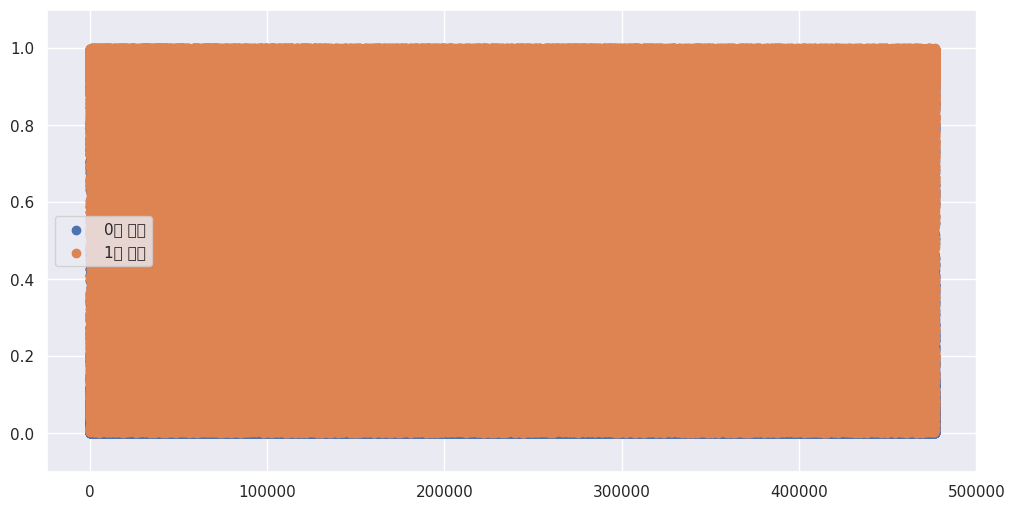

In [ ]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = best_model.predict_proba(train_X)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()

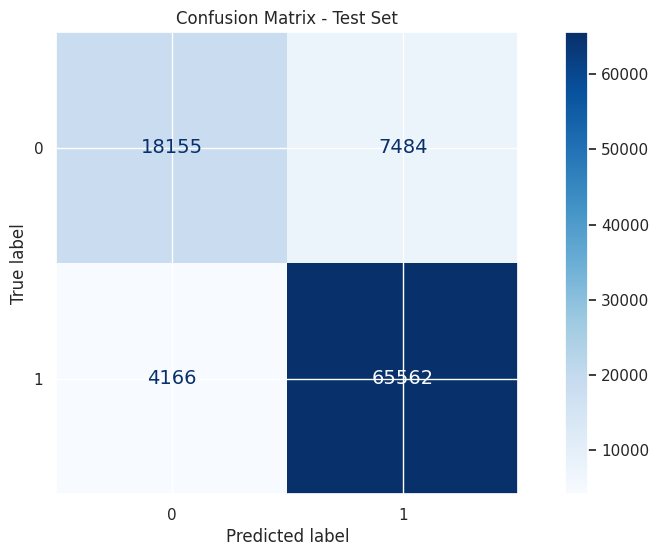

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. 최종 예측
y_pred = best_model.predict(test_X)

# 2. 혼동 행렬 계산
cm = confusion_matrix(test_y, y_pred)

# 3. 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')  # 'd'는 정수형 표시
plt.title("Confusion Matrix - Test Set")
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. 최종 예측
y_pred = best_model2.predict(test_X)

# 2. 혼동 행렬 계산
cm = confusion_matrix(test_y, y_pred)

# 3. 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')  # 'd'는 정수형 표시
plt.title("Confusion Matrix - Test Set")
plt.show()
